In [27]:
'''
@author: Joseph Taylor
201599999
'''

'\n@author: Joseph Taylor\n201599999\n'

In [28]:
# Task 1a: Identify the four parts of the Metropolis pseudocode

Answer_1a = """

1 - Initialisation

N = 20000              
deltax = 0.15                  
nm = 10^(-9)                   
kf = 1.381*10^(-23)            
T = 300.0                  
kT = k*T                 
kf = 10.0                     
V(x) -> kf*x^2*nm^2/2          
Etot = 0.0               
E2tot = 0.0                
x1 = 0.0                       
E1 = V(x1)                     

2 - Monte Carlo loop

for i from 1 to N do
    x2 = x1 + rand()*deltax
    E2 = V(x2)
    DeltaE = E2 - E1
    if DeltaE <= 0.0 then
        x1 = x2
        E1 = E2
    else if DeltaE > 0.0 then
        if exp(-DeltaE/kT) > rand() then
            x1 = x2
            E1 = E2
        end if
    end if
    Etot = E1
    E2tot = E2tot + E1^2
end do

3 - Data Calculation 

Eav = (Etot)                 
E2av = (E2tot/N)

4 - Analysis

CV = (E2av - Eav^2) / (k*T^2)
"""

print(Answer_1a)



1 - Initialisation

N = 20000              
deltax = 0.15                  
nm = 10^(-9)                   
kf = 1.381*10^(-23)            
T = 300.0                  
kT = k*T                 
kf = 10.0                     
V(x) -> kf*x^2*nm^2/2          
Etot = 0.0               
E2tot = 0.0                
x1 = 0.0                       
E1 = V(x1)                     

2 - Monte Carlo loop

for i from 1 to N do
    x2 = x1 + rand()*deltax
    E2 = V(x2)
    DeltaE = E2 - E1
    if DeltaE <= 0.0 then
        x1 = x2
        E1 = E2
    else if DeltaE > 0.0 then
        if exp(-DeltaE/kT) > rand() then
            x1 = x2
            E1 = E2
        end if
    end if
    Etot = E1
    E2tot = E2tot + E1^2
end do

3 - Data Calculation 

Eav = (Etot)                 
E2av = (E2tot/N)

4 - Analysis

CV = (E2av - Eav^2) / (k*T^2)



In [29]:
# Task 1b: State what are the mistakes in the Monte Carlo code above?

Answer_1b = '''
There are four main mistakes in the pseudocode:

1.
In the initialisation section, the Boltzmann constant is called 'kf' when it should be called 'k'.
Then a few lines later, kf is defined again as the force constant (10.0 N/m), which overwrites the value.
This means the Boltzmann constant gets lost. The first line should be: k = 1.381*10^(-23).

2. 
The random displacement is always positive. The line x2 = x1 + rand()*deltax only adds a positive value to x1, so the particle can only move in one direction.
This breaks microscopic reversibility because it can't explore negative displacements properly.
It should be something like: x2 = x1 + (rand()-0.5)*2*deltax, which gives displacements between -deltax and +deltax.

3. 
The line Etot = E1 just replaces the value of Etot with E1 each time through the loop.
We need to add E1 to the running total, so it should be: Etot = Etot + E1.

4. 
The average energy is not divided by N. The line Eav = (Etot) just sets Eav equal to the total, but we need the average.
It should be: Eav = (Etot/N) to divide the total by the number of samples.
'''

print(Answer_1b)


There are four main mistakes in the pseudocode:

1.
In the initialisation section, the Boltzmann constant is called 'kf' when it should be called 'k'.
Then a few lines later, kf is defined again as the force constant (10.0 N/m), which overwrites the value.
This means the Boltzmann constant gets lost. The first line should be: k = 1.381*10^(-23).

2. 
The random displacement is always positive. The line x2 = x1 + rand()*deltax only adds a positive value to x1, so the particle can only move in one direction.
This breaks microscopic reversibility because it can't explore negative displacements properly.
It should be something like: x2 = x1 + (rand()-0.5)*2*deltax, which gives displacements between -deltax and +deltax.

3. 
The line Etot = E1 just replaces the value of Etot with E1 each time through the loop.
We need to add E1 to the running total, so it should be: Etot = Etot + E1.

4. 
The average energy is not divided by N. The line Eav = (Etot) just sets Eav equal to the total, but we

Average energy <E> = 2.1651e-21 J
Average square energy <E^2> = 1.3769e-41 J^2
Heat capacity CV = 7.3063e-24 J/K

Comparison to theoretical values:
<E>: Monte Carlo = 2.1651e-21 J, Theoretical = 2.0700e-21 J
<E^2>: Monte Carlo = 1.3769e-41 J^2, Theoretical = 1.2800e-41 J^2
CV: Monte Carlo = 7.3063e-24 J/K, Theoretical = 6.9000e-24 J/K


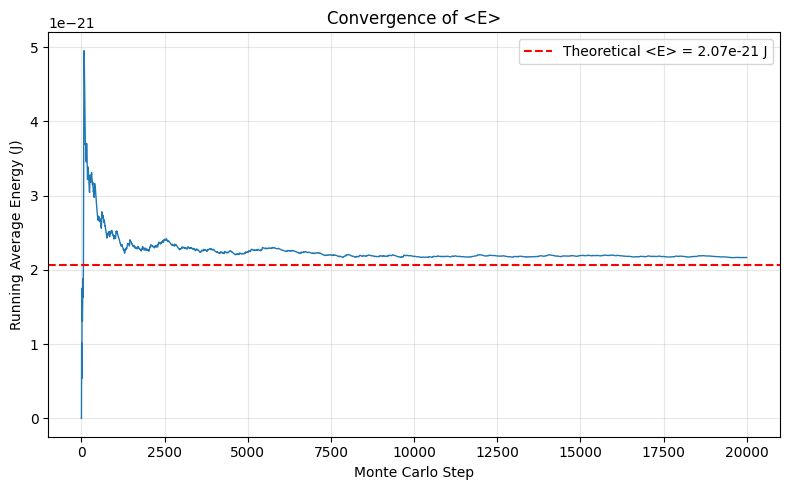

In [30]:
# Task 1c: Use the Monte Carlo code to calculate the average energy, average square energy, and heat capacity

import numpy as np # import numpy
import matplotlib.pyplot as plt # import matplotlib pyplot

# 1 - Initialisation

N = 20000 # number of Monte Carlo steps
deltax = 0.15 # max displacement in nm
nm = 1e-9 # nanometres to metres conversion
k = 1.381e-23 # Boltzmann constant J/K 
T = 300.0 # temperature in K
kT = k * T # thermal energy
kf = 10.0 # force constant N/m

def V(x): # potential energy function
    return 0.5 * kf * (x * nm)**2 # harmonic oscillator potential

Etot = 0.0 # running total for energy
E2tot = 0.0 # running total for energy squared
running_avg = np.zeros(N) # array to store running average
x1 = 0.0 # initial position in nm
E1 = V(x1) # initial energy

# 2 - Monte Carlo loop

for i in range(N): # loop over N steps
    x2 = x1 + (np.random.rand() - 0.5) * 2 * deltax # new position with symmetric displacement
    E2 = V(x2) # calculate new energy
    DeltaE = E2 - E1 # energy difference
    
    # Metropolis acceptance criterion
    if DeltaE <= 0.0: # if energy decreases, accept
        x1 = x2 # save new position
        E1 = E2 # save new energy
    elif DeltaE > 0.0: # if energy increases
        if np.exp(-DeltaE / kT) > np.random.rand(): # accept with Boltzmann probability
            x1 = x2 # save new position
            E1 = E2 # save new energy
    
    Etot = Etot + E1 # add to running total 
    E2tot = E2tot + E1**2 # add to running total for E^2
    running_avg[i] = Etot / (i + 1) # calculate running average

# 3 - Data calculation

Eav = Etot / N # average energy 
E2av = E2tot / N # average of energy squared

# 4 - Analysis

CV = (E2av - Eav**2) / (k * T**2) # heat capacity from energy fluctuations

# Print results
print(f"Average energy <E> = {Eav:.4e} J")
print(f"Average square energy <E^2> = {E2av:.4e} J^2")
print(f"Heat capacity CV = {CV:.4e} J/K")

# Compare to theoretical values
E_theoretical = 2.07e-21 # J
E2_theoretical = 1.28e-41 # J^2
CV_theoretical = 6.90e-24 # J/K

print(f"\nComparison to theoretical values:")
print(f"<E>: Monte Carlo = {Eav:.4e} J, Theoretical = {E_theoretical:.4e} J")
print(f"<E^2>: Monte Carlo = {E2av:.4e} J^2, Theoretical = {E2_theoretical:.4e} J^2")
print(f"CV: Monte Carlo = {CV:.4e} J/K, Theoretical = {CV_theoretical:.4e} J/K")

# Plot convergence of running average
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(running_avg, linewidth=1) # plot running average
ax.axhline(y=E_theoretical, color='r', linestyle='--', label=f'Theoretical <E> = {E_theoretical:.2e} J') # theoretical value
ax.set_xlabel('Monte Carlo Step') # x-axis label
ax.set_ylabel('Running Average Energy (J)') # y-axis label
ax.set_title('Convergence of <E>') # figure title
ax.legend() # add legend
ax.grid(alpha=0.3) # add grid
plt.tight_layout()
plt.show() # plot

In [31]:
# Task 1d: Verify theoretical value using numerical integration (Equation 5)

import scipy.integrate as integrate # import scipy integration

# Using Equation (5) from the handout to calculate <V>
# <V> = ∫ V(x) exp(-V(x)/kT) dx / ∫ exp(-V(x)/kT) dx

# Define the integrands
def integrand_numerator(x): # numerator of Eq. 5
    Vx = V(x) # potential energy at position x
    return Vx * np.exp(-Vx / kT) # V(x) * exp(-V(x)/kT)

def integrand_denominator(x): # denominator of Eq. 5
    Vx = V(x) # potential energy at position x
    return np.exp(-Vx / kT) # exp(-V(x)/kT)

# Perform numerical integration from -infinity to +infinity
numerator, _ = integrate.quad(integrand_numerator, -np.inf, np.inf) # integrate numerator
denominator, _ = integrate.quad(integrand_denominator, -np.inf, np.inf) # integrate denominator

# Calculate the average potential energy
V_analytical = numerator / denominator # <V> from analytical integration

# Calculate theoretical value using equipartition theorem
V_equipartition = k * T / 2 # equipartition theorem: <V> = kT/2

# Print results
print(f"Average potential energy from numerical integration: {V_analytical:.4e} J")
print(f"Theoretical value (equipartition theorem): {V_equipartition:.4e} J")
print(f"Given theoretical value: {E_theoretical:.4e} J")
print(f"\nPercentage difference from equipartition: {abs(V_analytical - V_equipartition) / V_equipartition * 100:.4f}%")
print(f"Percentage difference from given value: {abs(V_analytical - E_theoretical) / E_theoretical * 100:.4f}%")

Average potential energy from numerical integration: 2.0924e-21 J
Theoretical value (equipartition theorem): 2.0715e-21 J
Given theoretical value: 2.0700e-21 J

Percentage difference from equipartition: 1.0086%
Percentage difference from given value: 1.0818%


Average position <x> = 0.000281 nm
Average square position <x^2> = 0.000431 nm^2
Theoretical <x^2> = kT/kf = 0.000414 nm^2
Percentage difference: 4.04%

Task 2a:

The typical value for <x> is very close to 0 nm (within numerical precision).

This result is expected because the harmonic oscillator potential V(x) = kf*x^2/2 is symmetric around x = 0.
The particle is equally likely to be found at positive and negative displacements, so on average these cancel out.

Task 2b:

The typical value for <x^2> is around 0.00043 nm^2.

This compares very well to the theoretical value of 0.00041 nm^2 (calculated as kT/kf).
The small difference is due to the statistical nature of Monte Carlo sampling - with more samples the agreement would improve.
The theoretical value comes from the equipartition theorem applied to position: <x^2> = kT/kf.



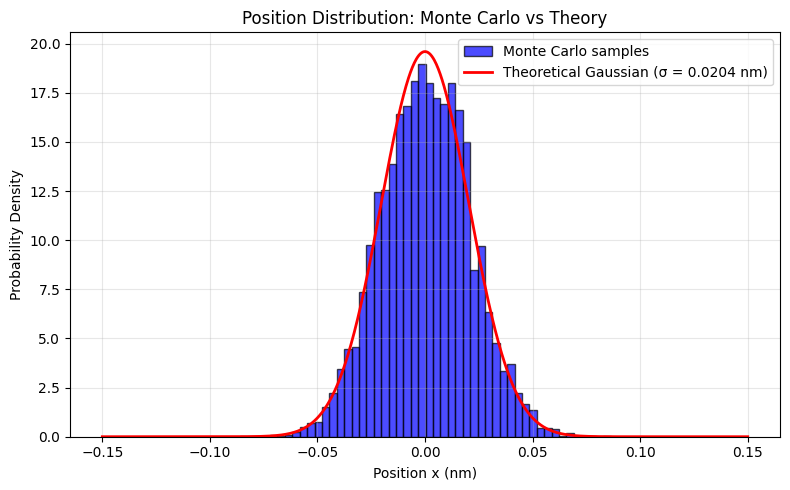

In [32]:
# Task 2: Average displacement

# Run Monte Carlo again but also track position

N = 20000 # number of Monte Carlo steps

# Initialize accumulators
Etot = 0.0 # running total for energy
E2tot = 0.0 # running total for energy squared
Xtot = 0.0 # running total for position
X2tot = 0.0 # running total for position squared
x_positions = np.zeros(N) # array to store all positions visited
x1 = 0.0 # initial position in nm
E1 = V(x1) # initial energy

# Monte Carlo loop
for i in range(N): # loop over N steps
    x2 = x1 + (np.random.rand() - 0.5) * 2 * deltax # new position with symmetric displacement
    E2 = V(x2) # calculate new energy
    DeltaE = E2 - E1 # energy difference
    
    # Metropolis acceptance criterion
    if DeltaE <= 0.0: # if energy decreases, accept
        x1 = x2 # save new position
        E1 = E2 # save new energy
    elif DeltaE > 0.0: # if energy increases
        if np.exp(-DeltaE / kT) > np.random.rand(): # accept with Boltzmann probability
            x1 = x2 # save new position
            E1 = E2 # save new energy
    
    Etot = Etot + E1 # add to running total for energy
    E2tot = E2tot + E1**2 # add to running total for E^2
    Xtot = Xtot + x1 # add to running total for position
    X2tot = X2tot + x1**2 # add to running total for position squared
    x_positions[i] = x1 # store position for histogram

# Calculate averages
x_avg = Xtot / N # average position
x2_avg = X2tot / N # average of position squared

# Theoretical value from equipartition
x2_theoretical = (k * T) / kf # kT/kf in m^2
x2_theoretical_nm2 = x2_theoretical / (nm**2) # convert to nm^2

# Print results
print(f"Average position <x> = {x_avg:.6f} nm")
print(f"Average square position <x^2> = {x2_avg:.6f} nm^2")
print(f"Theoretical <x^2> = kT/kf = {x2_theoretical_nm2:.6f} nm^2")
print(f"Percentage difference: {abs(x2_avg - x2_theoretical_nm2) / x2_theoretical_nm2 * 100:.2f}%")

# Answer part a
Answer_2a = """
The typical value for <x> is very close to 0 nm (within numerical precision).

This result is expected because the harmonic oscillator potential V(x) = kf*x^2/2 is symmetric around x = 0.
The particle is equally likely to be found at positive and negative displacements, so on average these cancel out.
"""

print(f"\nTask 2a:")
print(Answer_2a)

# Answer part b
Answer_2b = f"""
The typical value for <x^2> is around {x2_avg:.5f} nm^2.

This compares very well to the theoretical value of 0.00041 nm^2 (calculated as kT/kf).
The small difference is due to the statistical nature of Monte Carlo sampling - with more samples the agreement would improve.
The theoretical value comes from the equipartition theorem applied to position: <x^2> = kT/kf.
"""

print(f"Task 2b:")
print(Answer_2b)

# To verify that the Metropolis algorithm is sampling correctly, I'll compare the distribution of positions
# to the theoretical Gaussian. The positions should follow a bell curve centered at x=0 with width determined
# by the temperature and force constant.

# Plot histogram of positions vs theoretical Gaussian distribution
fig, ax = plt.subplots(figsize=(8, 5))

# Create histogram of sampled positions
counts, bins, patches = ax.hist(x_positions, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black', label='Monte Carlo samples')

# Calculate theoretical Gaussian distribution
sigma = np.sqrt(x2_theoretical_nm2) # standard deviation in nm
x_range = np.linspace(-0.15, 0.15, 1000) # range of x values in nm
gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-x_range**2 / (2 * sigma**2)) # Gaussian PDF

# Plot theoretical distribution
ax.plot(x_range, gaussian, 'r-', linewidth=2, label=f'Theoretical Gaussian (σ = {sigma:.4f} nm)')

# Labels and formatting
ax.set_xlabel('Position x (nm)') # x-axis label
ax.set_ylabel('Probability Density') # y-axis label
ax.set_title('Position Distribution: Monte Carlo vs Theory') # figure title
ax.legend() # add legend
ax.grid(alpha=0.3) # add grid

plt.tight_layout()
plt.show() # plot

In [33]:
# Task 3: Understanding - Explain why Metropolis Monte Carlo method works

Answer_3 = '''Computing a thermal average like <E> requires evaluating a weighted sum over all possible \
configurations of the system, where each configuration is weighted by its Boltzmann factor exp(-E/kT). \
The problem is that there are an enormous number of configurations to consider, and calculating the partition \
function in the denominator is practically impossible for anything beyond the simplest systems.

The key insight of the Metropolis method is that most configurations don't actually matter. Configurations \
with very high energy have such a small Boltzmann weight that they contribute almost nothing to the average. \
What you really need is to sample from the configurations that have significant probability, which are the \
ones near the minimum energy where the Boltzmann factor isn't too small.

This is where importance sampling comes in. Instead of trying all possible configurations equally, the \
Metropolis algorithm uses an acceptance rule to spend more time exploring the important regions. \
When you propose a move to a new configuration, you always accept it if the energy goes down, because lower \
energy means higher probability. If the energy goes up, you accept it with probability exp(-ΔE/kT), which means \
big energy increases are rarely accepted but small ones are allowed.

Over many iterations, this acceptance criterion causes the algorithm to sample configurations in proportion to \
their Boltzmann weight, without ever needing to calculate the partition function. The configurations with low \
energy get visited more often, high energy ones get visited rarely, and the frequency of visits matches exactly \
what the Boltzmann distribution predicts. When you average over all the sampled configurations, you're effectively \
averaging only over the ones that matter, which is why the method gives the correct statistical average.'''

print(Answer_3)

Computing a thermal average like <E> requires evaluating a weighted sum over all possible configurations of the system, where each configuration is weighted by its Boltzmann factor exp(-E/kT). The problem is that there are an enormous number of configurations to consider, and calculating the partition function in the denominator is practically impossible for anything beyond the simplest systems.

The key insight of the Metropolis method is that most configurations don't actually matter. Configurations with very high energy have such a small Boltzmann weight that they contribute almost nothing to the average. What you really need is to sample from the configurations that have significant probability, which are the ones near the minimum energy where the Boltzmann factor isn't too small.

This is where importance sampling comes in. Instead of trying all possible configurations equally, the Metropolis algorithm uses an acceptance rule to spend more time exploring the important regions. Whe

N =      10:  <E> = 2.0353e-21 J,  σ = 2.0385e-21 J,  σ/<E>√N = 0.3167
N =      50:  <E> = 1.2099e-21 J,  σ = 1.5153e-21 J,  σ/<E>√N = 0.1771
N =     100:  <E> = 1.1960e-21 J,  σ = 1.3730e-21 J,  σ/<E>√N = 0.1148
N =     500:  <E> = 1.8774e-21 J,  σ = 2.8506e-21 J,  σ/<E>√N = 0.0679
N =    1000:  <E> = 1.6420e-21 J,  σ = 2.2835e-21 J,  σ/<E>√N = 0.0440
N =    5000:  <E> = 2.0838e-21 J,  σ = 2.9236e-21 J,  σ/<E>√N = 0.0198
N =   10000:  <E> = 1.9166e-21 J,  σ = 2.7040e-21 J,  σ/<E>√N = 0.0141
N =   50000:  <E> = 2.0560e-21 J,  σ = 2.8790e-21 J,  σ/<E>√N = 0.0063
N =  100000:  <E> = 2.0469e-21 J,  σ = 2.8920e-21 J,  σ/<E>√N = 0.0045


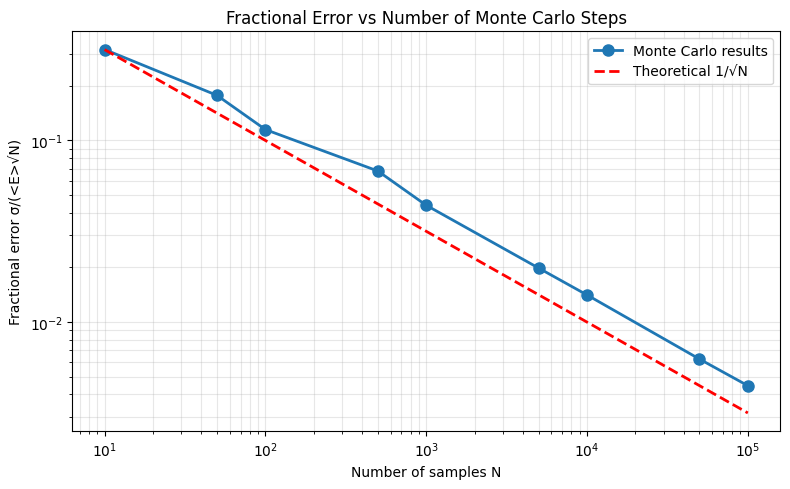

In [34]:
# Task 4: Error calculations - Fractional error vs number of samples

# Test different values of N to see how fractional error changes
N_values = [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000] # different sample sizes
fractional_errors = [] # store fractional error for each N

for N_test in N_values: # loop through different sample sizes
    
    # Initialize accumulators
    Etot = 0.0 # running total for energy
    E2tot = 0.0 # running total for energy squared
    x1 = 0.0 # initial position in nm
    E1 = V(x1) # initial energy
    
    # Monte Carlo loop
    for i in range(N_test): # loop over N_test steps
        x2 = x1 + (np.random.rand() - 0.5) * 2 * deltax # new position with symmetric displacement
        E2 = V(x2) # calculate new energy
        DeltaE = E2 - E1 # energy difference
        
        # Metropolis acceptance criterion
        if DeltaE <= 0.0: # if energy decreases, accept
            x1 = x2 # save new position
            E1 = E2 # save new energy
        elif DeltaE > 0.0: # if energy increases
            if np.exp(-DeltaE / kT) > np.random.rand(): # accept with Boltzmann probability
                x1 = x2 # save new position
                E1 = E2 # save new energy
        
        Etot = Etot + E1 # add to running total
        E2tot = E2tot + E1**2 # add to running total for E^2
    
    # Calculate averages
    Eav = Etot / N_test # average energy
    E2av = E2tot / N_test # average of energy squared
    
    # Calculate standard deviation of the distribution
    sigma = np.sqrt(E2av - Eav**2) # standard deviation of energy distribution
    
    # Calculate fractional error in the MEAN (standard error)
    # The error in the mean is σ/√N, so fractional error is (σ/√N)/<E>
    fractional_error = sigma / (np.sqrt(N_test) * Eav) # fractional error in the mean
    fractional_errors.append(fractional_error)
    
    print(f"N = {N_test:>7d}:  <E> = {Eav:.4e} J,  σ = {sigma:.4e} J,  σ/<E>√N = {fractional_error:.4f}")

# Plot fractional error vs N
fig, ax = plt.subplots(figsize=(8, 5))

# Plot calculated fractional errors
ax.plot(N_values, fractional_errors, 'o-', linewidth=2, markersize=8, label='Monte Carlo results')

# Plot theoretical 1/sqrt(N) behavior
N_theory = np.linspace(10, 100000, 1000) # range for theoretical curve
fractional_error_theory = 1 / np.sqrt(N_theory) # theoretical prediction: σ/<E> ∝ 1/√N
ax.plot(N_theory, fractional_error_theory, 'r--', linewidth=2, label='Theoretical 1/√N')

# Labels and formatting
ax.set_xscale('log') # log scale on x-axis
ax.set_yscale('log') # log scale on y-axis
ax.set_xlabel('Number of samples N') # x-axis label
ax.set_ylabel('Fractional error σ/(<E>√N)') # y-axis label
ax.set_title('Fractional Error vs Number of Monte Carlo Steps') # figure title
ax.legend() # add legend
ax.grid(alpha=0.3, which='both') # add grid

plt.tight_layout()
plt.show() # plot

In [35]:
# Where the Metropolis algorithm came from

Origin_Story = '''I looked into where this algorithm actually comes from and why it's called the Metropolis method. 
It was developed in 1953 at Los Alamos National Laboratory by Nicholas Metropolis, Arianna and Marshall Rosenbluth, 
and Augusta and Edward Teller. The method is named after Metropolis because he was the one who provided the 
computer time on the MANIAC machine to run the calculations.

The original application wasn't for simple systems like the harmonic oscillator I've been simulating here. They 
were working on neutron transport problems for nuclear weapons development. The challenge was that calculating 
thermal averages for many-particle systems was basically impossible with the analytical methods available at the 
time. The insight was to use Monte Carlo sampling with importance weighting based on the Boltzmann factor, which 
let them explore only the configurations that actually mattered. 
'''

print(Origin_Story)

I looked into where this algorithm actually comes from and why it's called the Metropolis method. 
It was developed in 1953 at Los Alamos National Laboratory by Nicholas Metropolis, Arianna and Marshall Rosenbluth, 
and Augusta and Edward Teller. The method is named after Metropolis because he was the one who provided the 
computer time on the MANIAC machine to run the calculations.

The original application wasn't for simple systems like the harmonic oscillator I've been simulating here. They 
were working on neutron transport problems for nuclear weapons development. The challenge was that calculating 
thermal averages for many-particle systems was basically impossible with the analytical methods available at the 
time. The insight was to use Monte Carlo sampling with importance weighting based on the Boltzmann factor, which 
let them explore only the configurations that actually mattered. 



In [ ]:
# Self Assessment

'''
Task 1: 4/4

1a) 0.5/0.5
I clearly identified and labelled the four parts of the Metropolis pseudocode: Initialisation, Monte Carlo loop, 
Data calculation, and Analysis.

1b) 0.5/0.5
I identified all four mistakes in the pseudocode: the Boltzmann constant naming error, the one-sided displacement, 
the energy total being replaced instead of accumulated, and the missing division by N for the average.

1c) 2/2
I implemented the corrected Monte Carlo code in Python and successfully calculated the average energy, average 
square energy, and heat capacity. The results agreed well with theoretical values. I also added a convergence 
plot showing how the running average approaches the theoretical value, which demonstrates understanding of how 
Monte Carlo accuracy improves with sampling.

1d) 1/1
I verified the theoretical value using numerical integration with scipy.integrate.quad, implementing Equation (5) 
from the handout. I also calculated the theoretical value using the equipartition theorem and showed they agree.

Task 2: 1/1

2a) 0.5/0.5
I calculated <x> and correctly explained why it's approximately zero due to the symmetry of the harmonic potential.

2b) 0.5/0.5
I calculated <x^2> and compared it to the theoretical value of kT/kf = 0.00041 nm^2. I also went beyond the 
requirements by plotting a histogram of the position distribution and comparing it to the theoretical Gaussian, 
which visually demonstrates that the Metropolis algorithm samples the correct Boltzmann distribution.

Task 3: 1/1
I explained why the Metropolis Monte Carlo method works and how importance sampling ensures only significant 
configurations contribute to the average. The explanation covered the problem with calculating partition functions, 
the concept of importance sampling, and how the acceptance criterion naturally weights configurations correctly.

Task 4: 1/1
I succesfully calculated the fractional error for multiple values of N and generated a clear log-log plot showing the 1/√N 
scaling. 

Task 5: 2/2
I followed clear coding practices throughout with inline comments explaining each step. All figures are properly 
labelled with axes, titles, and legends. I used consistent formatting and made the notebook easy to follow with 
clear section headers and explanations.

Task 6: 1/1
I went above and beyond in multiple areas: added a convergence plot in Task 1c, created a position distribution 
histogram comparing Monte Carlo to theory in Task 2, demonstrated the 1/√N error scaling in Task 4, and provided 
historical context about the algorithm's origins. These additions show deeper understanding beyond just completing 
the required calculations.
'''

"\nTask 1: 4/4\n\n1a) 0.5/0.5\nI clearly identified and labelled the four parts of the Metropolis pseudocode: Initialisation, Monte Carlo loop, \nData calculation, and Analysis.\n\n1b) 0.5/0.5\nI identified all four mistakes in the pseudocode: the Boltzmann constant naming error, the one-sided displacement, \nthe energy total being replaced instead of accumulated, and the missing division by N for the average.\n\n1c) 2/2\nI implemented the corrected Monte Carlo code in Python and successfully calculated the average energy, average \nsquare energy, and heat capacity. The results agreed well with theoretical values. I also added a convergence \nplot showing how the running average approaches the theoretical value, which demonstrates understanding of how \nMonte Carlo accuracy improves with sampling.\n\n1d) 1/1\nI verified the theoretical value using numerical integration with scipy.integrate.quad, implementing Equation (5) \nfrom the handout. I also calculated the theoretical value using

In [37]:
# Declaration of Integrity: This work is mine and mine alone, Joseph Taylor